# Moran's Index for slope

In [ ]:
import pip
pip.main(['install','matplotlib-scalebar'])

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sbn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx
import pysal
from pysal.explore import esda
from pysal.viz import splot
from pysal.lib import weights
from splot.esda import lisa_cluster
from splot.esda import plot_moran
from splot.esda import plot_local_autocorrelation, moran_scatterplot

import warnings
warnings.filterwarnings("ignore")

C:\Users\edier\miniconda3\Lib\site-packages\spaghetti\network.py:40: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


### Catchments

In [2]:
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/df2_catchments.gpkg")
cat.head(2)

,ID_CUENCA,Nombre,kmeans,Área,hypso_inte,_Ksmean,_chimean,rainfall_cat,Densidad,elev_mean,slope_mean,rel_mean,cuenca,lands_rec,lands_rel,landslides,geometry
0,0,Quebrada Los San Andreses,A,120.181924,0.107,6.202666,10.017347,2250.332866,2.446291,149.317619,7.478481,68.147069,Cauca,0.0,0.0,0.0,"MULTIPOLYGON (((411860.438 900002.542, 411964...."
1,1,Quebrada Sabalito,A,33.492364,0.334,2.188858,6.036456,3457.470653,0.000000,58.212878,4.334927,25.697303,Cauca,0.0,0.0,0.0,"MULTIPOLYGON (((505464.576 881616.272, 505673...."


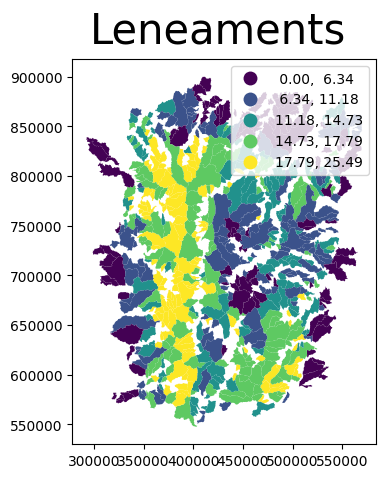

In [3]:
f, ax = plt.subplots(1, figsize=(5, 5))
cat.plot(column='Densidad', scheme='Quantiles', legend=True, ax=ax)
f.suptitle('Leneaments', size=30)
plt.show()

In [4]:
w_dist20km = weights.DistanceBand.from_dataframe(cat, 20000, binary=False)

In [5]:
cat['w_leneaments'] = weights.lag_spatial(w_dist20km, cat['Densidad'])

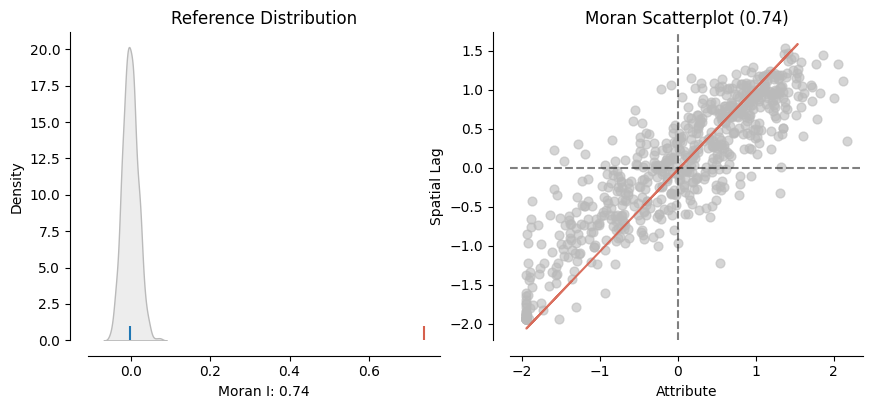

In [6]:
mi = esda.Moran(cat['Densidad'], w_dist20km)
plot_moran(mi);

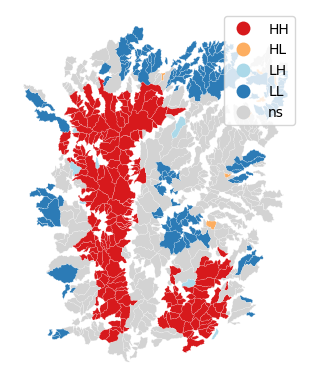

In [7]:
lisa = esda.Moran_Local(cat['Densidad'], w_dist20km)
lisa_cluster(lisa, cat);

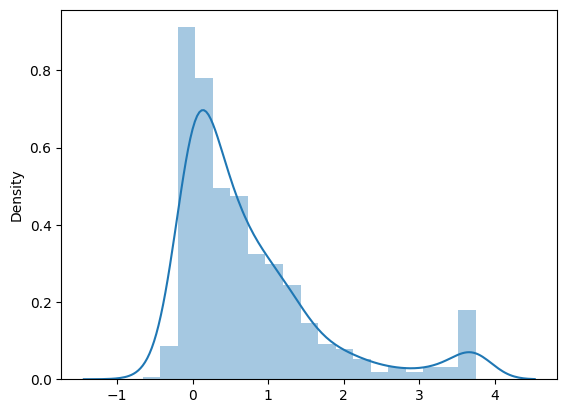

In [8]:
sbn.distplot(lisa.Is);

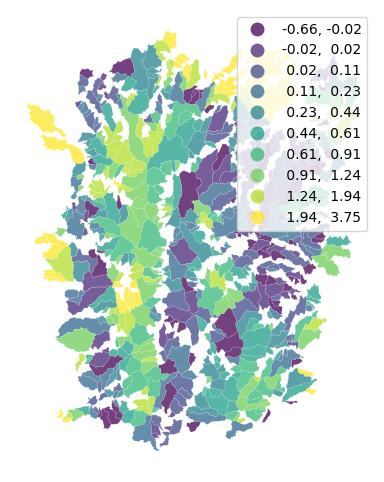

In [9]:
f, ax = plt.subplots(1, figsize=(6,6))
cat['Is'] = lisa.Is
cat.plot(column='Is', cmap='viridis', scheme='quantiles',k=10, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True,ax=ax);
ax.set_axis_off()

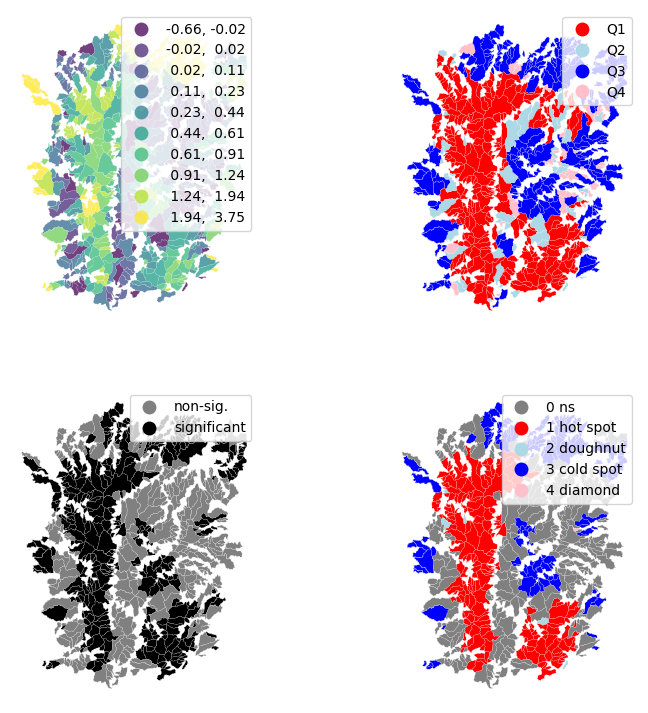

In [10]:
from matplotlib.colors import ListedColormap
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(9, 9))
axs = axs.flatten()

# Subplot 1 #
ax = axs[0]
cat.plot(column='Is', cmap='viridis', scheme='quantiles', k=10, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True, ax=ax)
ax.set_aspect('equal')
ax.set_axis_off()

# Subplot 2 #
ax = axs[1]
q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', 'pink'])
cat.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
ax.set_aspect('equal')
ax.set_axis_off()

# Subplot 3 #
ax = axs[2]
sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels = ['non-sig.', 'significant'] 
labels = [labels[i] for i in sig]
cat.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
ax.set_aspect('equal')
ax.set_axis_off()
                            
# Subplot 4 #
ax = axs[3]
hotspot = 1 * (sig * lisa.q==1)
coldspot = 3 * (sig * lisa.q==3)
doughnut = 2 * (sig * lisa.q==2)
diamond = 4 * (sig * lisa.q==4)
spots = hotspot + coldspot + doughnut + diamond
spot_labels = [ '0 ns', '1 hot spot', '2 doughnut', '3 cold spot', '4 diamond']
labels = [spot_labels[i] for i in spots]
hmap = ListedColormap([ 'grey', 'red', 'lightblue', 'blue', 'pink'])
cat.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
ax.set_aspect('equal')
ax.set_axis_off()

plt.show()

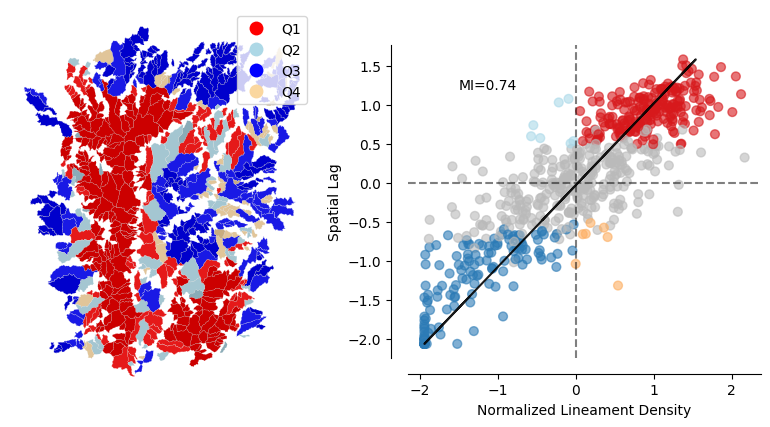

In [9]:
from matplotlib.colors import ListedColormap
f, ax = plt.subplots(nrows=1, ncols=2,figsize=(10,5))
axs = ax.flatten()

q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels1 = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', '#FAD7A0'])
cat.assign(cl=labels1).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax[0],edgecolor='white', legend=True)

sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels2 = ['non-sig.', 'significant'] 
labels2 = [labels2[i] for i in sig]
cat.assign(cl=labels2).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax[0],edgecolor='white', alpha=0.20)
ax[0].set_aspect('equal')
ax[0].set_axis_off()

moran_scatterplot(lisa, p=0.05,ax=ax[1])
ax[1].text(-1.5,1.2,f'MI={round(mi.I, 2)}')
ax[1].set_xlabel("Normalized Lineament Density")
ax[1].set_title('');
                            
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/lineament_moran.png", dpi=500);

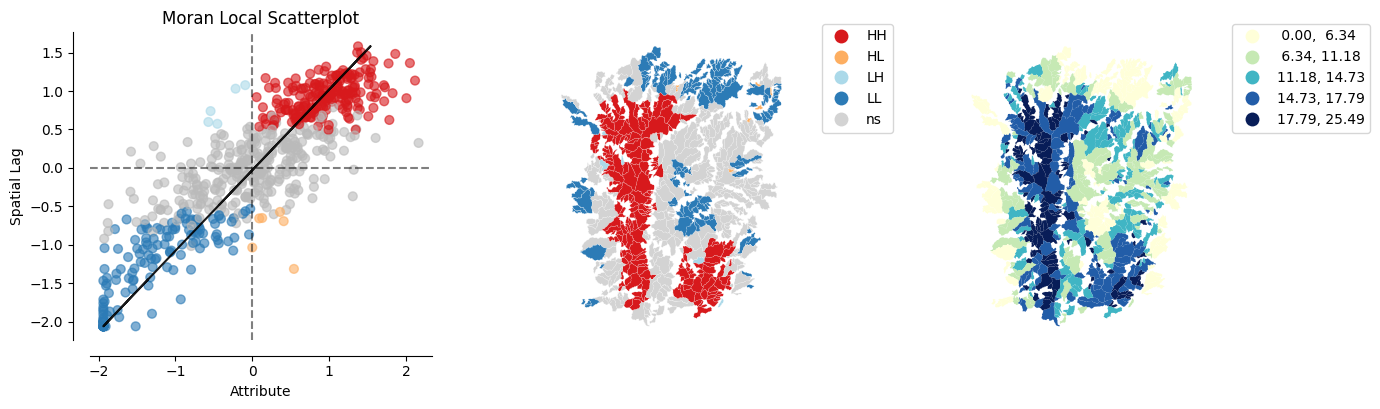

In [11]:
plot_local_autocorrelation(lisa, cat, 'Densidad')
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/lineaments_moran.png");

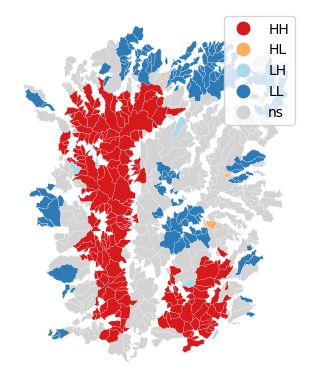

In [12]:
lisa_l = esda.Moran_Local(cat['Densidad'], w_dist20km)
lisa_cluster(lisa_l, cat);

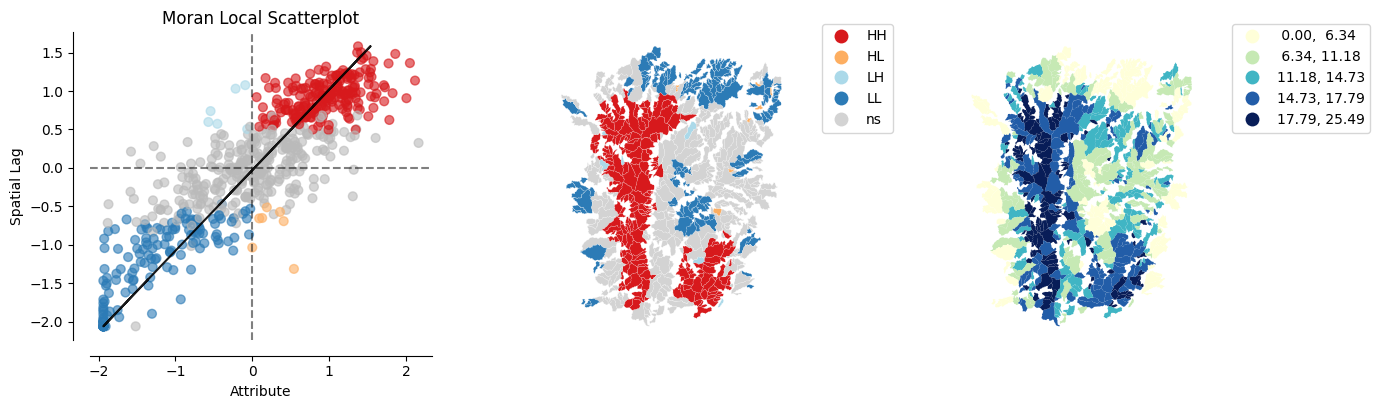

In [13]:
plot_local_autocorrelation(lisa_l, cat, 'Densidad');